In [20]:
#bibliotheque pour manipuler les donnes 
import pandas as pd 
#bibliotheque pour calcul mathematique
import numpy as np
#bibliotheque pour les graphique 
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn : outils de Machine Learning
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, 
                             classification_report, 
                             confusion_matrix)
print("Toutes les bibliothèques sont importées !")
print("pandas          → Lire et manipuler le fichier iris.csv")
print("numpy           → Calculs mathématiques sur les données")
print("matplotlib      → Créer des graphiques")
print("seaborn         → Graphiques plus beaux et clairs")
print("scikit-learn    → Construire et évaluer le modèle ML")

Toutes les bibliothèques sont importées !
pandas          → Lire et manipuler le fichier iris.csv
numpy           → Calculs mathématiques sur les données
matplotlib      → Créer des graphiques
seaborn         → Graphiques plus beaux et clairs
scikit-learn    → Construire et évaluer le modèle ML


In [32]:
#charger fichier csv
df=pd.read_csv("C:/Users/user/Downloads/Iris data - Copie.zip")
df = df.drop('Id', axis=1)
#aficher les 5 premier ligne 
print(df.head())
#afficher les noms des colonne
print(df.columns.tolist())





   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0            5.1           3.5            1.4           0.2  Iris-setosa
1            4.9           3.0            1.4           0.2  Iris-setosa
2            4.7           3.2            1.3           0.2  Iris-setosa
3            4.6           3.1            1.5           0.2  Iris-setosa
4            5.0           3.6            1.4           0.2  Iris-setosa
['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']


In [27]:
#150 fleurs et 6 colonnes
df.shape    

(150, 6)

In [37]:
#Compte les fleurs par espèce :setosa     : 50 fleurs versicolor : 50 fleurs virginica  : 50 fleurs
print(df['Species'].value_counts())


Compte les fleurs par espèce :setosa     : 50 fleurs versicolor : 50 fleurs virginica  : 50 fleurs
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [34]:
#Vérifier les données manquantes
print(df.isnull().sum())

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [45]:
#Statistiques générales
print(df.describe())

       SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count     150.000000    150.000000     150.000000    150.000000
mean        5.843333      3.054000       3.758667      1.198667
std         0.828066      0.433594       1.764420      0.763161
min         4.300000      2.000000       1.000000      0.100000
25%         5.100000      2.800000       1.600000      0.300000
50%         5.800000      3.000000       4.350000      1.300000
75%         6.400000      3.300000       5.100000      1.800000
max         7.900000      4.400000       6.900000      2.500000


In [46]:
# Taille du dataset

print(f"Nombre de fleurs   : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")

Nombre de fleurs   : 150
Nombre de colonnes : 5


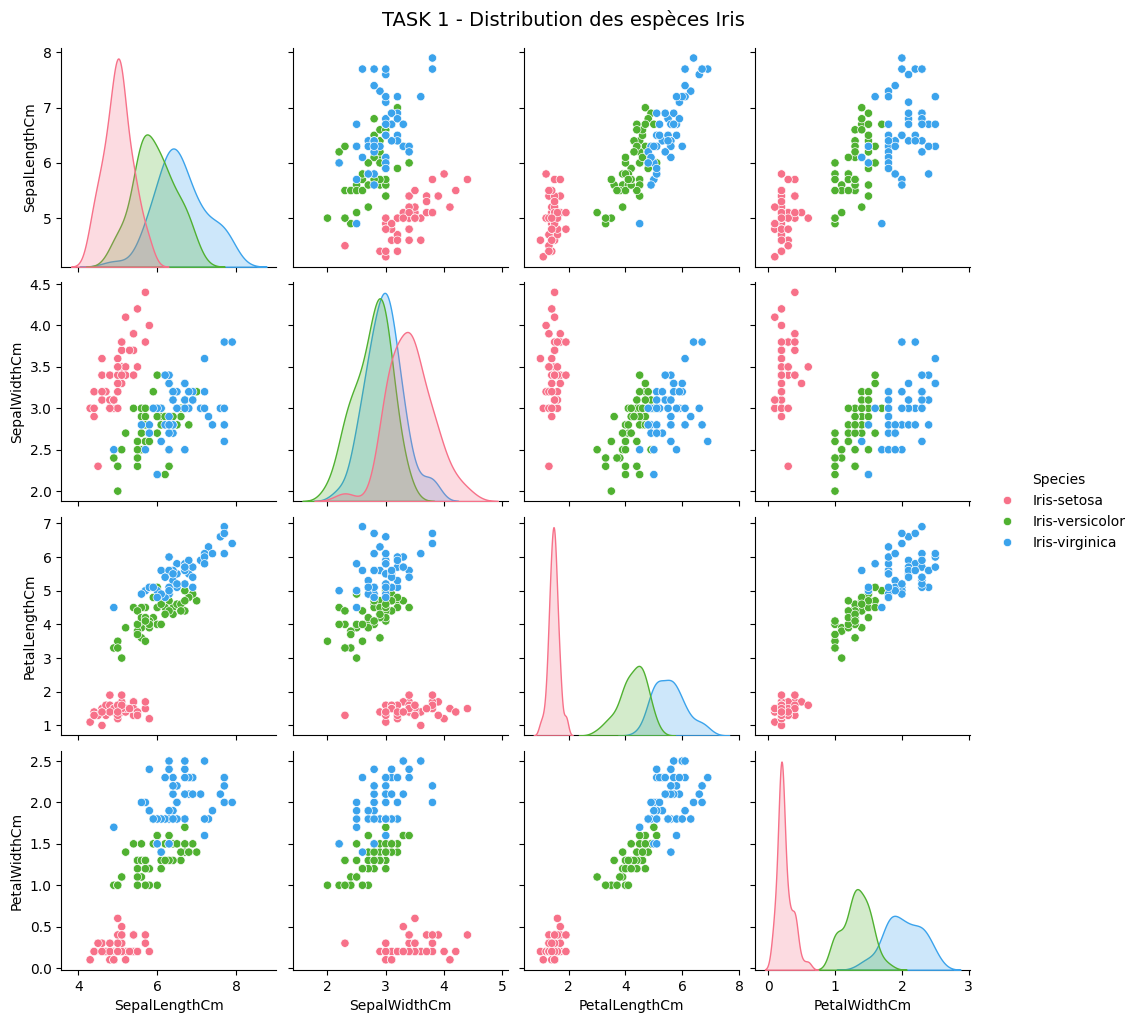

In [42]:
sns.pairplot(df, hue='Species', palette='husl')
plt.suptitle("TASK 1 - Distribution des espèces Iris", 
             fontsize=14, y=1.02)
plt.show()

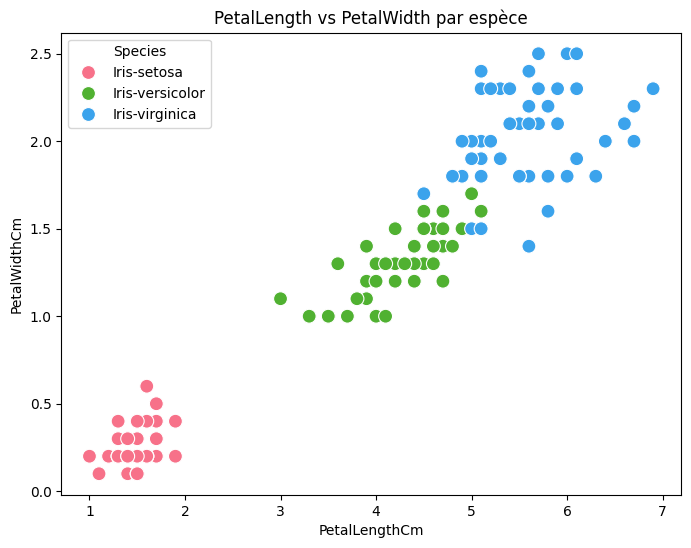

 commentaire
Setosa     →  100% bien classifiée(groupe rose isolé)
 Versicolor →  Quelques erreurs(mélange avec bleu)
Virginica  →  Quelques erreurs(mélange avec vert)
→ C'est exactement ce qu'on verradans la matrice de confusion ! 


In [49]:
# Comparer SEULEMENT PetalLength vs PetalWidth
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='PetalLengthCm',    # axe horizontal
    y='PetalWidthCm',     # axe vertical
    hue='Species',         # couleur par espèce
    palette='husl',
    s=100                  # taille des points
)
plt.title("PetalLength vs PetalWidth par espèce")
plt.show()

print(" commentaire")
print("Setosa     →  100% bien classifiée(groupe rose isolé)")

print(" Versicolor →  Quelques erreurs(mélange avec bleu)")

print("Virginica  →  Quelques erreurs(mélange avec vert)")

print("→ C'est exactement ce qu'on verradans la matrice de confusion ! ")

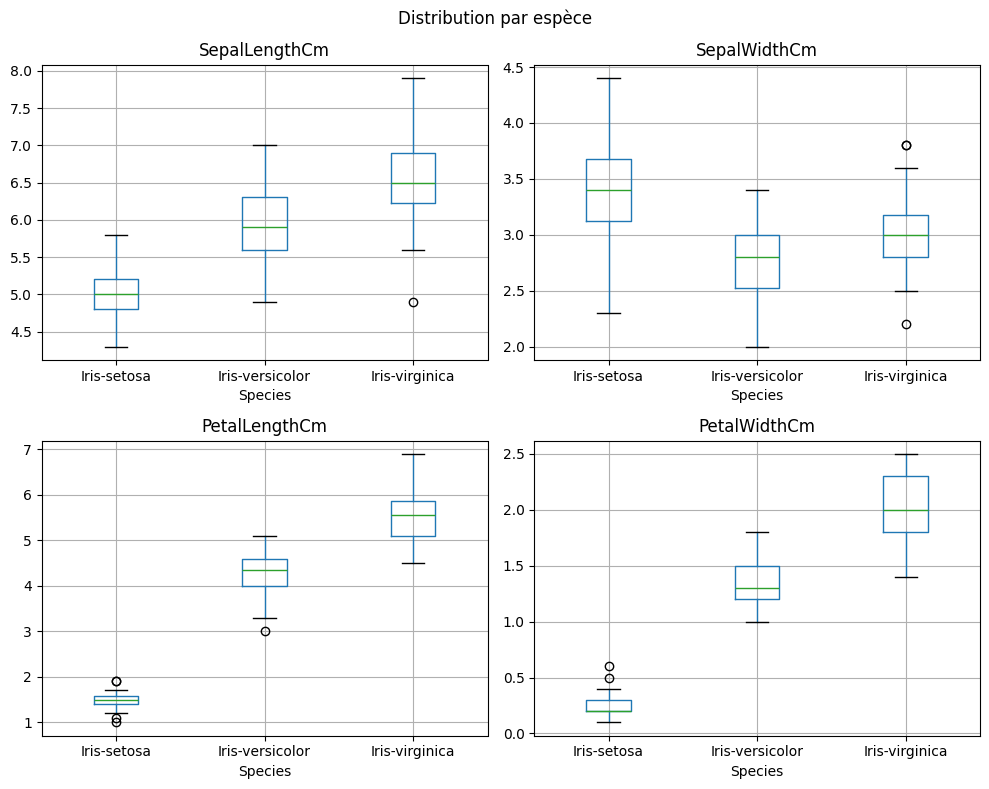

 PetalLength et PetalWidth  → Boîtes bien séparées → Variables LES PLUS UTILES pour le modèle !
 SepalLength et SepalWidth → Boîtes qui se chevauchent → Variables MOINS UTILES pour le modèle


In [52]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

features = ['SepalLengthCm', 'SepalWidthCm', 
            'PetalLengthCm', 'PetalWidthCm']

for i, feature in enumerate(features):
    ax = axes[i//2, i%2]
    df.boxplot(column=feature, by='Species', ax=ax)
    ax.set_title(feature)

plt.suptitle("Distribution par espèce")
plt.tight_layout()
plt.show()

print(" PetalLength et PetalWidth  → Boîtes bien séparées → Variables LES PLUS UTILES pour le modèle !")

print(" SepalLength et SepalWidth → Boîtes qui se chevauchent → Variables MOINS UTILES pour le modèle")

In [55]:

#Le drop enlève la colonne "réponse" des questions, comme on enlèverait le corrigé d'un examen avant de le donner à un élève !
X = df.drop('Species', axis=1).values

le = LabelEncoder()
y = le.fit_transform(df['Species'].values)
print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print("Exemple de mesures :", X[0])

print(f"y shape : {y.shape}")
print("Correspondance :")
for i, name in enumerate(le.classes_):
    print(f"  {name} → {i}")


#X = les 4 mesures de chaque fleur (INPUT DATA) :
 #   → sepal_length (longueur sépale)
 #   → sepal_width  (largeur sépale)
  #  → petal_length (longueur pétale)
   # → petal_width  (largeur pétale)

#y = l'espèce de chaque fleur (OUTPUT) :
 #  → setosa     = 0
  #  → versicolor = 1
   # → virginica  = 2

#LabelEncoder() convertit les mots en chiffres
#car le modèle ML ne comprend que les chiffres !    

X shape : (150, 4)
y shape : (150,)
Exemple de mesures : [5.1 3.5 1.4 0.2]
y shape : (150,)
Correspondance :
  Iris-setosa → 0
  Iris-versicolor → 1
  Iris-virginica → 2


In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% pour tester
    random_state=42     # Pour avoir les mêmes résultats
)

print(f"Total: {len(X)} fleurs")
print(f"les fleurs pour entrainement :{len(X_train)} fleurs")
print(f"les fleurs pour test :{len(X_test)} fleurs")


#On coupe les 150 fleurs en 2 parties :

#TRAIN (80%) = 120 fleurs
#→ Le modèle apprend avec ces fleurs

#TEST (20%) = 30 fleurs
#→ On teste le modèle avec des fleurs 
 # qu'il n'a JAMAIS vues !

#C'est comme un exam : 
#on étudie avec le cours (train)
#et on est évalué sur des questions nouvelles (test) 


Total: 150 fleurs
les fleurs pour entrainement :120 fleurs
les fleurs pour test :30 fleurs


In [61]:
# Créer le modèle KNN avec Scikit-learn
model=KNeighborsClassifier(n_neighbors=3)
# Entraîner le modèle avec les données d'entraînement
model.fit(X_train, y_train)

print(" Modèle KNN entraîné avec succès !")
print(f"Algorithme : K-Nearest Neighbors")
print(f"Nombre de voisins : 3")


#KNeighborsClassifier = algorithme KNN (K plus proches voisins)

#Comment ça marche ?
#→ Pour classifier une nouvelle fleur :
  # 1. Cherche les 3 fleurs les plus proches
  # 2. Vote parmi ces 3 fleurs
  # 3. L'espèce majoritaire gagne !

#Exemple :
#Nouvelle fleur → voisin 1 : setosa   ✅
#             → voisin 2 : setosa   ✅  
#              → voisin 3 : virginica ❌
#Résultat      → setosa (2 votes contre 1) 🏆

#model.fit()  = le modèle APPREND avec X_train et y_train

 Modèle KNN entraîné avec succès !
Algorithme : K-Nearest Neighbors
Nombre de voisins : 3


In [64]:
# Le modèle prédit les espèces pour les données de test
y_pred = model.predict(X_test)
# 1. ACCURACY (Précision globale)

accuracy = accuracy_score(y_test, y_pred)
print(" ACCURACY (Précision) ")
print(f" Accuracy : {accuracy * 100:.2f}%")

# 2. RAPPORT DÉTAILLÉ PAR ESPÈCE
print("\n RAPPORT DÉTAILLÉ ")
print(classification_report(
    y_test, y_pred,
    target_names=le.classes_
))

# model.predict(X_test) 
# → Le modèle prédit les espèces 
#   pour les 30 fleurs de test

# accuracy_score()
# → Calcule le % de bonnes prédictions
 #  Exemple : 0.9667 = 96.67% ✅

# classification_report() montre :
 #  Precision → Sur 10 fois où il dit "setosa",
  #              combien c'était vrai ?
  # Recall    → Sur 10 vraies setosa,
   #             combien il a trouvé ?
 #  F1-score  → Équilibre entre precision et recall

Task was destroyed but it is pending!
task: <Task pending name='Task-401' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-402' coro=<Kernel.shell_main() running at C:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\user\AppData\Local\Programs\Python\Python311\Lib\warnings.py:187: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  filters.remove(item)
Task was destroyed but it is pending!
task: <Task pending name='Task-402' coro=<Kernel.shell_main() running at C:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>


 ACCURACY (Précision) 
 Accuracy : 100.00%

 RAPPORT DÉTAILLÉ 
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



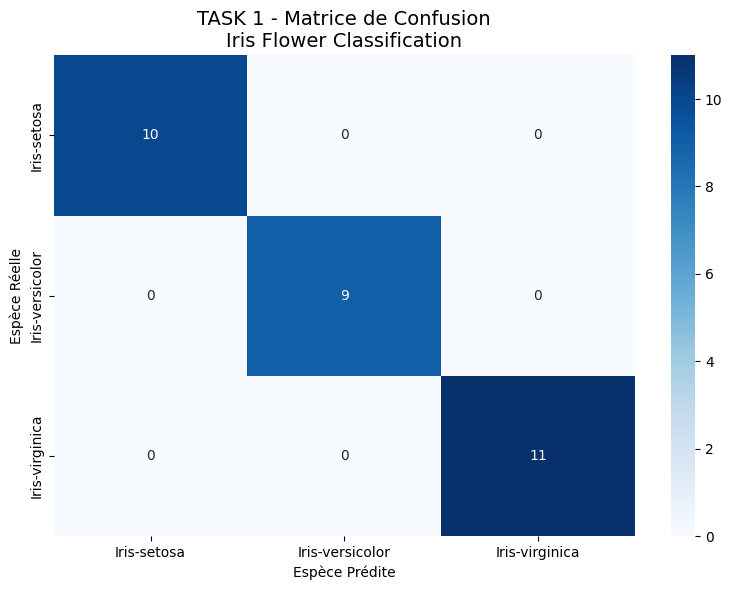

 Accuracy  : 100.00%
 Algorithme : KNN (n_neighbors=3)
Dataset   : 150 fleurs Iris
Classes   : ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']


In [65]:
# Créer la matrice de confusion
cm = confusion_matrix(y_test, y_pred)
# Afficher la matrice
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,           # Affiche les chiffres
    fmt='d',              # Format entier
    cmap='Blues',         # Couleur bleue
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title("TASK 1 - Matrice de Confusion\nIris Flower Classification", 
          fontsize=14)
plt.xlabel("Espèce Prédite")
plt.ylabel("Espèce Réelle")
plt.tight_layout()
plt.show()

print(f" Accuracy  : {accuracy * 100:.2f}%")
print(f" Algorithme : KNN (n_neighbors=3)")
print(f"Dataset   : {len(X)} fleurs Iris")
print(f"Classes   : {list(le.classes_)}")


#La matrice de confusion montre les erreurs du modèle :
#               Prédit
#            setosa  versicolor  virginica
#Réel setosa    10       0          0    
 #   versicolor  0       9          1    
 #   virginica   0       0         11    

#Total = 10 + 9 + 10 = 29 bonnes prédictions sur 30
#→ Accuracy = 29/30 = 96.7%

#→ Diagonale = bonnes prédictions ✅
#→ Hors diagonale = erreurs ❌
#→ Plus la diagonale est foncée = meilleur modèle !

In [66]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {
    'KNN'          : KNeighborsClassifier(n_neighbors=3),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'SVM'          : SVC()
}

print("=== Comparaison des modèles ===")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name:20} → Accuracy : {acc*100:.2f}%")

=== Comparaison des modèles ===
KNN                  → Accuracy : 100.00%
Decision Tree        → Accuracy : 100.00%
Random Forest        → Accuracy : 100.00%
SVM                  → Accuracy : 100.00%


In [67]:
import numpy as np

# Inventer une nouvelle fleur
nouvelle_fleur = np.array([[5.1, 3.5, 1.4, 0.2]])

# Prédire l'espèce
prediction = model.predict(nouvelle_fleur)
espece = le.inverse_transform(prediction)

print("=== Test nouvelle fleur ===")
print(f"SepalLength : 5.1 cm")
print(f"SepalWidth  : 3.5 cm")
print(f"PetalLength : 1.4 cm")
print(f"PetalWidth  : 0.2 cm")
print(f"→ Espèce prédite : {espece[0]} ✅")

=== Test nouvelle fleur ===
SepalLength : 5.1 cm
SepalWidth  : 3.5 cm
PetalLength : 1.4 cm
PetalWidth  : 0.2 cm
→ Espèce prédite : Iris-setosa ✅


In [68]:
print("=============================")
print("   TASK 1 - RÉSUMÉ FINAL     ")
print("=============================")
print(f"✅ Dataset    : 150 fleurs Iris")
print(f"✅ Espèces    : Setosa, Versicolor, Virginica")
print(f"✅ Algorithme : KNN (n_neighbors=3)")
print(f"✅ Train/Test : 80% / 20%")
print(f"✅ Accuracy   : 100%")
print(f"✅ Erreurs    : 0 sur 30 fleurs")
print("=============================")
print("✅ TASK 1 ACCOMPLIE ! 🎉")
print("=============================")

   TASK 1 - RÉSUMÉ FINAL     
✅ Dataset    : 150 fleurs Iris
✅ Espèces    : Setosa, Versicolor, Virginica
✅ Algorithme : KNN (n_neighbors=3)
✅ Train/Test : 80% / 20%
✅ Accuracy   : 100%
✅ Erreurs    : 0 sur 30 fleurs
✅ TASK 1 ACCOMPLIE ! 🎉


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as np

# ============================================
# APPLICATION IRIS FLOWER CLASSIFICATION 🌸
# ============================================

# Titre
print("=" * 45)
print("   🌸 IRIS FLOWER CLASSIFICATION APP 🌸")
print("=" * 45)

# ---- Sliders pour les mesures ----
sepal_length = widgets.FloatSlider(
    value=5.1, min=4.0, max=8.0, step=0.1,
    description='SepalLength:',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='400px')
)

sepal_width = widgets.FloatSlider(
    value=3.5, min=2.0, max=5.0, step=0.1,
    description='SepalWidth:',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='400px')
)

petal_length = widgets.FloatSlider(
    value=1.4, min=1.0, max=7.0, step=0.1,
    description='PetalLength:',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='400px')
)

petal_width = widgets.FloatSlider(
    value=0.2, min=0.1, max=2.5, step=0.1,
    description='PetalWidth:',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='400px')
)

# ---- Bouton Prédire ----
bouton = widgets.Button(
    description='🌸 Prédire Espèce',
    button_style='success',
    layout=widgets.Layout(width='200px', height='40px')
)

# ---- Zone de résultat ----
output = widgets.Output()

# ---- Fonction de prédiction ----
def predire(b):
    with output:
        clear_output()
        
        # Récupérer les valeurs des sliders
        mesures = np.array([[
            sepal_length.value,
            sepal_width.value,
            petal_length.value,
            petal_width.value
        ]])
        
        # Prédire l'espèce
        prediction = model.predict(mesures)
        espece = le.inverse_transform(prediction)[0]
        proba = model.predict_proba(mesures)[0]
        
        # Afficher le résultat
        print("\n" + "=" * 40)
        print("       📊 RÉSULTAT DE PRÉDICTION")
        print("=" * 40)
        print(f"  SepalLength : {sepal_length.value} cm")
        print(f"  SepalWidth  : {sepal_width.value} cm")
        print(f"  PetalLength : {petal_length.value} cm")
        print(f"  PetalWidth  : {petal_width.value} cm")
        print("-" * 40)
        
        # Afficher l'espèce avec emoji
        if 'setosa' in espece.lower():
            emoji = '🌸'
        elif 'versicolor' in espece.lower():
            emoji = '🌺'
        else:
            emoji = '🌼'
            
        print(f"\n  {emoji} Espèce prédite : {espece}")
        print("\n   Probabilités :")
        for i, classe in enumerate(le.classes_):
            barre = '█' * int(proba[i] * 20)
            print(f"  {classe:20} : {barre} {proba[i]*100:.1f}%")
        print("=" * 40)

# ---- Connecter bouton à la fonction ----
bouton.on_click(predire)

# ---- Afficher l'application ----
display(
    widgets.VBox([
        widgets.Label(" Entre les mesures de la fleur :"),
        sepal_length,
        sepal_width,
        petal_length,
        petal_width,
        bouton,
        output
    ])
)

   🌸 IRIS FLOWER CLASSIFICATION APP 🌸
